# Model-Recovery Grid — Summary

Visualises the 4σ × 2 cmax model-recovery grid produced by `run_model_recovery_grid.py`. Reads `model_recovery_grid_results/grid_sl*.json` directly — works even when cells are partially complete (the runner writes incrementally).

**Sections**
1. Load grid cells
2. Confusion matrices — small-multiples grid (4 σ-levels × 2 conflict_max)
3. Per-cell parameter recovery scatter (configurable cell + model)


## 1. Load grid cells

In [1]:
import json, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi':       130,
    'font.size':        11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

GRID_DIR = 'model_recovery_grid_results'
FIG_DIR  = 'identifiability_figures'
os.makedirs(FIG_DIR, exist_ok=True)

MODEL_ABBR = {
    'lognorm':                    'CI',
    'fusionOnlyLogNorm':          'Fusion',
    'switchingFree':              'Switching',
    'probabilityMatchingLogNorm': 'Prob. Match.',
    'selection':                  'Selection',
}
MODEL_COLORS = {
    'lognorm':                    '#1f77b4',
    'fusionOnlyLogNorm':          '#ff7f0e',
    'switchingFree':              '#2ca02c',
    'probabilityMatchingLogNorm': '#d62728',
    'selection':                  '#9467bd',
}

# JSON-key -> display name (matches names written by run_model_recovery_grid.py)
PARAM_DISPLAY = {
    'lambda':  r'$\lambda$',
    'sigma_a': r'$\sigma_a$',
    'sigma_v': r'$\sigma_v$',
    'p_c':     r'$p_c$',
    'p_sw':    r'$p_{sw}$',
}
UNIQUE_PARAMS = {
    'fusionOnlyLogNorm':          ['lambda', 'sigma_a', 'sigma_v'],
    'lognorm':                    ['lambda', 'sigma_a', 'sigma_v', 'p_c'],
    'probabilityMatchingLogNorm': ['lambda', 'sigma_a', 'sigma_v', 'p_c'],
    'selection':                  ['lambda', 'sigma_a', 'sigma_v', 'p_c'],
    'switchingFree':              ['lambda', 'sigma_a', 'sigma_v', 'p_sw'],
}


def load_grid_cells(grid_dir=GRID_DIR, n_iter=None, nSimul=None, prefer='largest_n'):
    """
    Load every grid cell JSON.  If multiple files share the same
    (σ-level, conflict_max) — typical when the directory accumulates results
    from runs with different settings — keep at most one per cell.

    Parameters
    ----------
    n_iter, nSimul : int or None
        If given, only files matching exactly these settings are kept.
    prefer : 'largest_n' | 'most_recent'
        Tie-break when n_iter/nSimul are not pinned: 'largest_n' keeps the
        file with the highest min n_completed across models (i.e. the most
        complete run).  'most_recent' uses file mtime.
    """
    raw = []
    for fp in sorted(glob.glob(os.path.join(grid_dir, 'grid_sl*.json'))):
        with open(fp) as f:
            d = json.load(f)
        models       = d['models']
        n_completed  = {m: d.get('per_model', {}).get(m, {}).get('n_completed', 0)
                        for m in models}
        min_complete = min(n_completed.values()) if n_completed else 0
        raw.append({
            'sigma_key':     d['sigma_key'],
            'sigma_label':   d['sigma_label'],
            'sigma_a_range': tuple(d['sigma_a_range']),
            'sigma_v_range': tuple(d['sigma_v_range']),
            'conflict_max':  d['conflict_max'],
            'n_iter':        d['n_iter'],
            'nSimul':        d['nSimul'],
            'n_completed':   n_completed,
            'min_complete':  min_complete,
            'mtime':         os.path.getmtime(fp),
            'mean_diag':     d['mean_diag_recovery_aic'],
            'confusion_aic': d['confusion_aic'],
            'per_model':     d.get('per_model', {}),
            'models':        models,
            'path':          fp,
        })

    if n_iter is not None:
        raw = [r for r in raw if r['n_iter'] == n_iter]
    if nSimul is not None:
        raw = [r for r in raw if r['nSimul'] == nSimul]

    # Deduplicate by (sigma_key, conflict_max)
    by_cell = {}
    for r in raw:
        key = (r['sigma_key'], round(r['conflict_max'], 4))
        if key not in by_cell:
            by_cell[key] = r
            continue
        cur = by_cell[key]
        if prefer == 'most_recent':
            if r['mtime'] > cur['mtime']:
                by_cell[key] = r
        else:  # 'largest_n'
            if (r['min_complete'] >  cur['min_complete']
                or (r['min_complete'] == cur['min_complete']
                    and r['mtime'] >  cur['mtime'])):
                by_cell[key] = r
    return list(by_cell.values())


# ── Pin to the run you care about.  Set N_ITER / NSIMUL to integers to
#    require exact match; leave as None to auto-pick the most-complete file
#    per (σ-level, cmax).
N_ITER = None
NSIMUL = None

cells = load_grid_cells(n_iter=N_ITER, nSimul=NSIMUL, prefer='largest_n')
grid  = pd.DataFrame(cells)
print(f"Loaded {len(cells)} grid cells from {GRID_DIR}/")
if not cells:
    print("→ No grid_sl*.json files found.  Run run_model_recovery_grid.py first.")
else:
    sigma_keys = sorted(grid['sigma_key'].unique())
    cmaxes     = sorted(grid['conflict_max'].unique(), reverse=True)
    print(f"  σ-levels: {sigma_keys}")
    print(f"  cmax    : {cmaxes}")
    print()
    cols = ['sigma_key', 'sigma_label', 'conflict_max', 'n_iter', 'nSimul', 'mean_diag']
    print(grid[cols].sort_values(['sigma_key', 'conflict_max']).to_string(index=False))


Loaded 2 grid cells from model_recovery_grid_results/
  σ-levels: ['a']
  cmax    : [np.float64(0.45), np.float64(0.25)]

sigma_key   sigma_label  conflict_max  n_iter  nSimul  mean_diag
        a a [0.01–0.20]          0.25      50    1000      0.768
        a a [0.01–0.20]          0.45      50     300      0.740


## 2. Confusion matrices — 4 σ-levels × 2 conflict_max

One panel per cell. Rows = generating model, columns = recovered model. Cells show classification rate (% of n iterations).


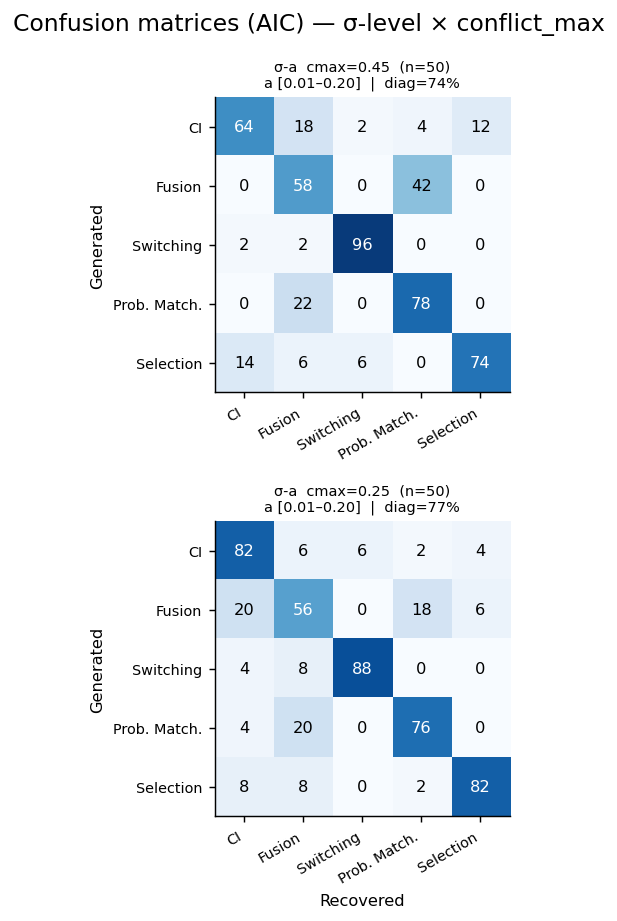

In [6]:
# Confusion-matrix small-multiples grid: rows = cmax (high→low), cols = σ-level a→d.
# Each panel is a normalised confusion matrix (row-normalised: each row sums to 1).

if not cells:
    print('No grid cells loaded.')
else:
    sigma_keys = sorted(grid['sigma_key'].unique())
    cmaxes     = sorted(grid['conflict_max'].unique(), reverse=True)
    sweep_models = list(grid['models'].iloc[0])
    abbrs = [MODEL_ABBR.get(m, m[:3]) for m in sweep_models]
    nm    = len(sweep_models)

    nrows, ncols = len(cmaxes), len(sigma_keys)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.6 * ncols, 3.6 * nrows),
                             squeeze=False)

    for i, cm in enumerate(cmaxes):
        for j, sk in enumerate(sigma_keys):
            ax  = axes[i][j]
            row = grid[(grid['sigma_key'] == sk) & np.isclose(grid['conflict_max'], cm)]
            if not len(row):
                ax.set_visible(False)
                continue
            cell_row = row.iloc[0]
            mat = np.zeros((nm, nm))
            for ii, gen in enumerate(sweep_models):
                conf_row = cell_row['confusion_aic'].get(gen, {})
                tot = sum(conf_row.values()) or 1
                for jj, fit in enumerate(sweep_models):
                    mat[ii, jj] = conf_row.get(fit, 0) / tot
            ax.imshow(mat, vmin=0, vmax=1, cmap='Blues')
            ax.set_xticks(range(nm))
            ax.set_xticklabels(abbrs, fontsize=8, rotation=30, ha='right')
            ax.set_yticks(range(nm))
            ax.set_yticklabels(abbrs, fontsize=8)
            for ii in range(nm):
                for jj in range(nm):
                    if mat[ii, jj] > -0.01:
                        ax.text(jj, ii, f'{mat[ii, jj]*100:.0f}',
                                ha='center', va='center', fontsize=9,
                                color='white' if mat[ii, jj] > 0.5 else 'black')
            n_target = int(cell_row['n_iter'])
            n_done   = min(cell_row['n_completed'].values()) if cell_row['n_completed'] else n_target
            ntag     = f'{n_done}/{n_target}' if n_done < n_target else f'n={n_target}'
            mean_diag = cell_row['mean_diag']
            ax.set_title(
                f'σ-{sk}  cmax={cm:.2f}  ({ntag})\n'
                f'{cell_row["sigma_label"]}  |  diag={mean_diag*100:.0f}%',
                fontsize=8)
            if j == 0:
                ax.set_ylabel('Generated', fontsize=9)
            if i == nrows - 1:
                ax.set_xlabel('Recovered', fontsize=9)

    fig.suptitle('Confusion matrices (AIC) — σ-level × conflict_max',
                 fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/grid_confusion_matrices.pdf', bbox_inches='tight')
    plt.savefig(f'{FIG_DIR}/grid_confusion_matrices.png', bbox_inches='tight', dpi=180)
    plt.show()


## 3. Parameter recovery — per cell

Pick `(σ-level, cmax, generating model)` to plot all unique-parameter scatters (gen vs recovered) for that one cell. Same-model fits only.


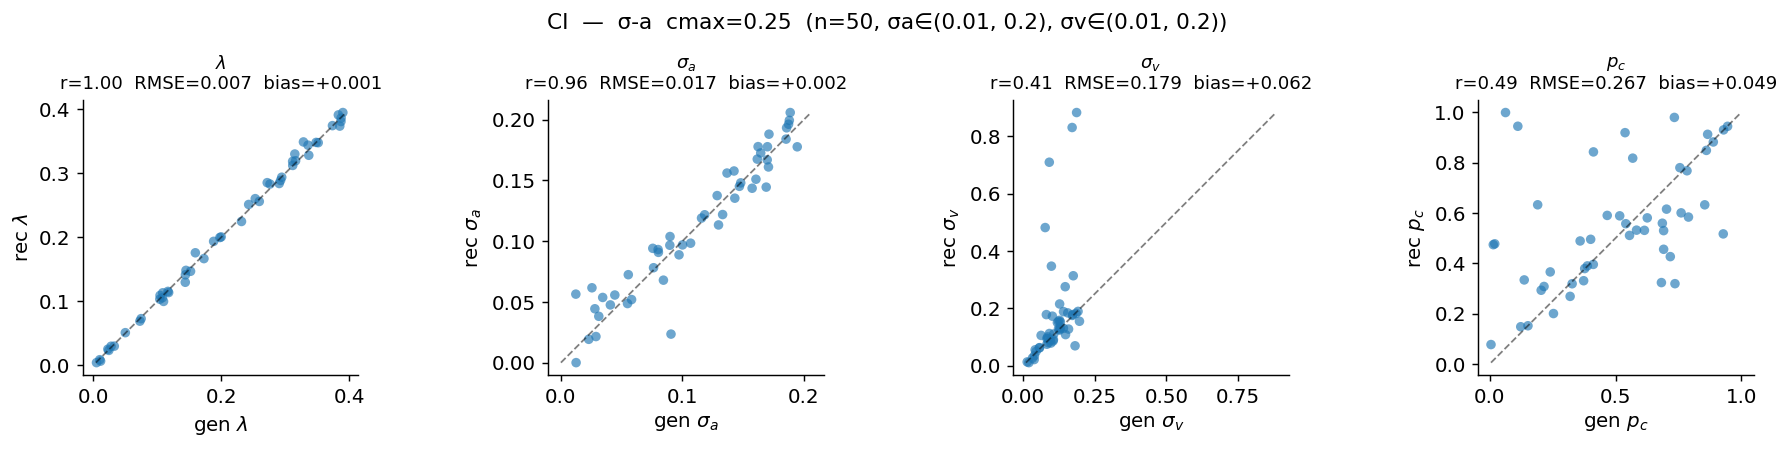

In [3]:
# Per-cell parameter recovery scatter.  Edit the three SELECT_* variables
# below to pick a different (σ-level, cmax, generating model).

# ── Configuration ────────────────────────────────────────────────────────
SELECT_SIGMA_KEY = 'a'                # one of 'a', 'b', 'c', 'd'
SELECT_CMAX      = 0.25               # one of the cmax values in the grid
SELECT_GEN_MODEL = 'lognorm'          # any of the 5 models

# ── Plot ─────────────────────────────────────────────────────────────────
def _find_cell(sigma_key, cmax):
    sub = grid[(grid['sigma_key'] == sigma_key) &
               np.isclose(grid['conflict_max'], cmax)]
    if not len(sub):
        return None
    return sub.iloc[0]


def plot_param_recovery_for_cell(sigma_key, cmax, gen_model):
    cell = _find_cell(sigma_key, cmax)
    if cell is None:
        print(f"No grid cell for σ-{sigma_key} | cmax={cmax}")
        print(f"Available: σ-levels={sorted(grid['sigma_key'].unique())}, "
              f"cmaxes={sorted(grid['conflict_max'].unique())}")
        return
    pm = cell['per_model'].get(gen_model, {})
    pr = pm.get('param_recovery', {})
    if not pr:
        print(f"No param_recovery data for {gen_model} in this cell.")
        return

    params = UNIQUE_PARAMS.get(gen_model, list(pr.keys()))
    n_params = len(params)
    n_cols   = min(4, n_params)
    n_rows   = (n_params + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.6 * n_cols, 3.4 * n_rows),
                             squeeze=False)
    color = MODEL_COLORS.get(gen_model, '#444')

    for k, param in enumerate(params):
        ax = axes[k // n_cols][k % n_cols]
        if param not in pr:
            ax.set_visible(False); continue
        gv = np.asarray(pr[param]['gen_values'])
        rv = np.asarray(pr[param]['rec_values'])
        if len(gv) == 0:
            ax.set_visible(False); continue
        r    = pr[param]['correlation']
        rmse = pr[param]['rmse']
        bias = pr[param]['bias']
        ax.scatter(gv, rv, s=28, alpha=0.65, color=color, edgecolor='none')
        lo = float(min(gv.min(), rv.min()))
        hi = float(max(gv.max(), rv.max()))
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1.0, alpha=0.5)
        ax.set_xlabel(f'gen {PARAM_DISPLAY.get(param, param)}')
        ax.set_ylabel(f'rec {PARAM_DISPLAY.get(param, param)}')
        ax.set_title(f'{PARAM_DISPLAY.get(param, param)}\n'
                     f'r={r:.2f}  RMSE={rmse:.3f}  bias={bias:+.3f}',
                     fontsize=10)
        ax.set_aspect('equal', adjustable='box')

    # hide unused subplots
    for k in range(n_params, n_rows * n_cols):
        axes[k // n_cols][k % n_cols].set_visible(False)

    n_completed = pm.get('n_completed', len(gv))
    fig.suptitle(
        f'{MODEL_ABBR.get(gen_model, gen_model)}  —  σ-{sigma_key}  '
        f'cmax={cmax:.2f}  (n={n_completed}, σa∈{cell["sigma_a_range"]}, '
        f'σv∈{cell["sigma_v_range"]})',
        fontsize=12)
    plt.tight_layout()
    tag = f'{gen_model.replace("LogNorm","")}_sl{sigma_key}_cmax{cmax:.2f}'
    plt.savefig(f'{FIG_DIR}/grid_param_recov_{tag}.pdf', bbox_inches='tight')
    plt.savefig(f'{FIG_DIR}/grid_param_recov_{tag}.png', bbox_inches='tight', dpi=180)
    plt.show()


plot_param_recovery_for_cell(SELECT_SIGMA_KEY, SELECT_CMAX, SELECT_GEN_MODEL)


## 4. Optional: parameter recovery across **all** cells

Picks one `(generating model, parameter)` and tiles the recovery scatter across the 8 cells. Useful for seeing how recoverability of e.g. `p_c` changes with σ-range.


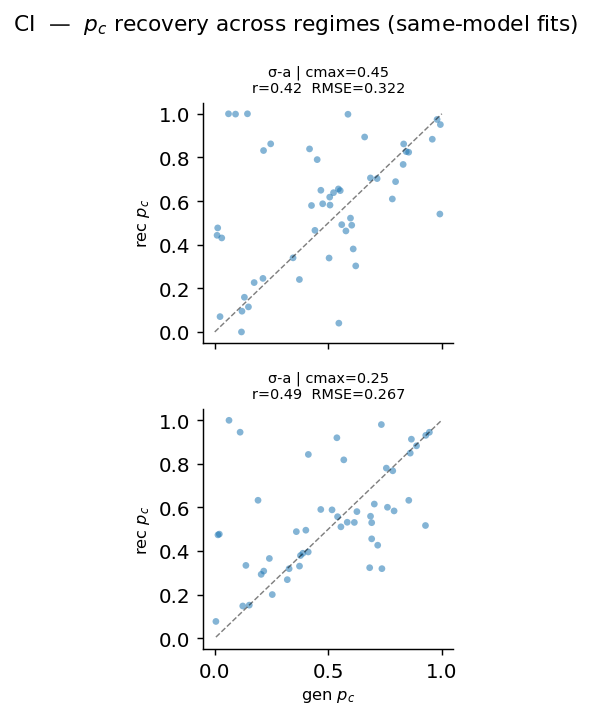

In [4]:
# All-cells parameter recovery: tile gen-vs-rec scatter for one
# (gen_model, parameter) across the 4σ × 2cmax grid.

# ── Configuration ────────────────────────────────────────────────────────
ALL_GEN_MODEL = 'lognorm'      # one of the 5 models
ALL_PARAM     = 'p_c'          # 'lambda', 'sigma_a', 'sigma_v', 'p_c', or 'p_sw'

# ── Plot ─────────────────────────────────────────────────────────────────
def plot_param_recovery_all_cells(gen_model, param):
    sigma_keys = sorted(grid['sigma_key'].unique())
    cmaxes     = sorted(grid['conflict_max'].unique(), reverse=True)
    nrows, ncols = len(cmaxes), len(sigma_keys)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(2.8 * ncols, 2.8 * nrows),
                             squeeze=False, sharex=True, sharey=True)
    color = MODEL_COLORS.get(gen_model, '#444')

    for i, cm in enumerate(cmaxes):
        for j, sk in enumerate(sigma_keys):
            ax  = axes[i][j]
            sub = grid[(grid['sigma_key'] == sk) & np.isclose(grid['conflict_max'], cm)]
            if not len(sub):
                ax.text(0.5, 0.5, '—', ha='center', va='center',
                        color='gray', transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
                continue
            cell = sub.iloc[0]
            pr   = cell['per_model'].get(gen_model, {}).get('param_recovery', {})
            if param not in pr:
                ax.text(0.5, 0.5, 'n/a', ha='center', va='center',
                        color='gray', transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
                continue
            gv = np.asarray(pr[param]['gen_values'])
            rv = np.asarray(pr[param]['rec_values'])
            r    = pr[param]['correlation']
            rmse = pr[param]['rmse']
            ax.scatter(gv, rv, s=14, alpha=0.55, color=color, edgecolor='none')
            lo = float(min(gv.min(), rv.min()))
            hi = float(max(gv.max(), rv.max()))
            ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
            ax.set_title(f'σ-{sk} | cmax={cm:.2f}\nr={r:.2f}  RMSE={rmse:.3f}',
                         fontsize=8)
            if i == nrows - 1:
                ax.set_xlabel(f'gen {PARAM_DISPLAY.get(param, param)}', fontsize=9)
            if j == 0:
                ax.set_ylabel(f'rec {PARAM_DISPLAY.get(param, param)}', fontsize=9)

    fig.suptitle(
        f'{MODEL_ABBR.get(gen_model, gen_model)}  —  '
        f'{PARAM_DISPLAY.get(param, param)} recovery across regimes '
        f'(same-model fits)',
        fontsize=12)
    plt.tight_layout()
    tag = f'{gen_model.replace("LogNorm","")}_{param}'
    plt.savefig(f'{FIG_DIR}/grid_param_recov_all_{tag}.pdf', bbox_inches='tight')
    plt.savefig(f'{FIG_DIR}/grid_param_recov_all_{tag}.png', bbox_inches='tight', dpi=180)
    plt.show()


plot_param_recovery_all_cells(ALL_GEN_MODEL, ALL_PARAM)
